# Graph Neural Network (GNN) - TensorFlow / Keras


Model: "Karate_Club_GCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ node_features       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adjacency_matrix    │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_gcn          │ (None, 16)        │        544 │ node_features[0]… │
│ (GCNLayer)          │                   │            │ adjacency_matrix… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ hidden_gcn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_gcn          │ (None, 2)         │         32 │ dropout_3[0][0],  │
│ (GCNLayer)          │                   │            │ adjacency_matrix… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 576 (2.25 KB)

 Trainable params: 576 (2.25 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch   0 | Loss: 0.6996 | Train Acc: 0.3750
Epoch  20 | Loss: 0.5116 | Train Acc: 0.9583
Epoch  40 | Loss: 0.2120 | Train Acc: 0.9583
Epoch  60 | Loss: 0.1267 | Train Acc: 1.0000
Epoch  80 | Loss: 0.0582 | Train Acc: 1.0000
Epoch 100 | Loss: 0.0928 | Train Acc: 1.0000
Epoch 120 | Loss: 0.0570 | Train Acc: 0.9583
Epoch 140 | Loss: 0.0378 | Train Acc: 1.0000
Epoch 160 | Loss: 0.0237 | Train Acc: 1.0000
Epoch 180 | Loss: 0.0361 | Train Acc: 1.0000
Epoch 200 | Loss: 0.0107 | Train Acc: 1.0000

--- Final Test Accuracy: 1.0000 ---
Embeddings shape extracted successfully: (34, 16)


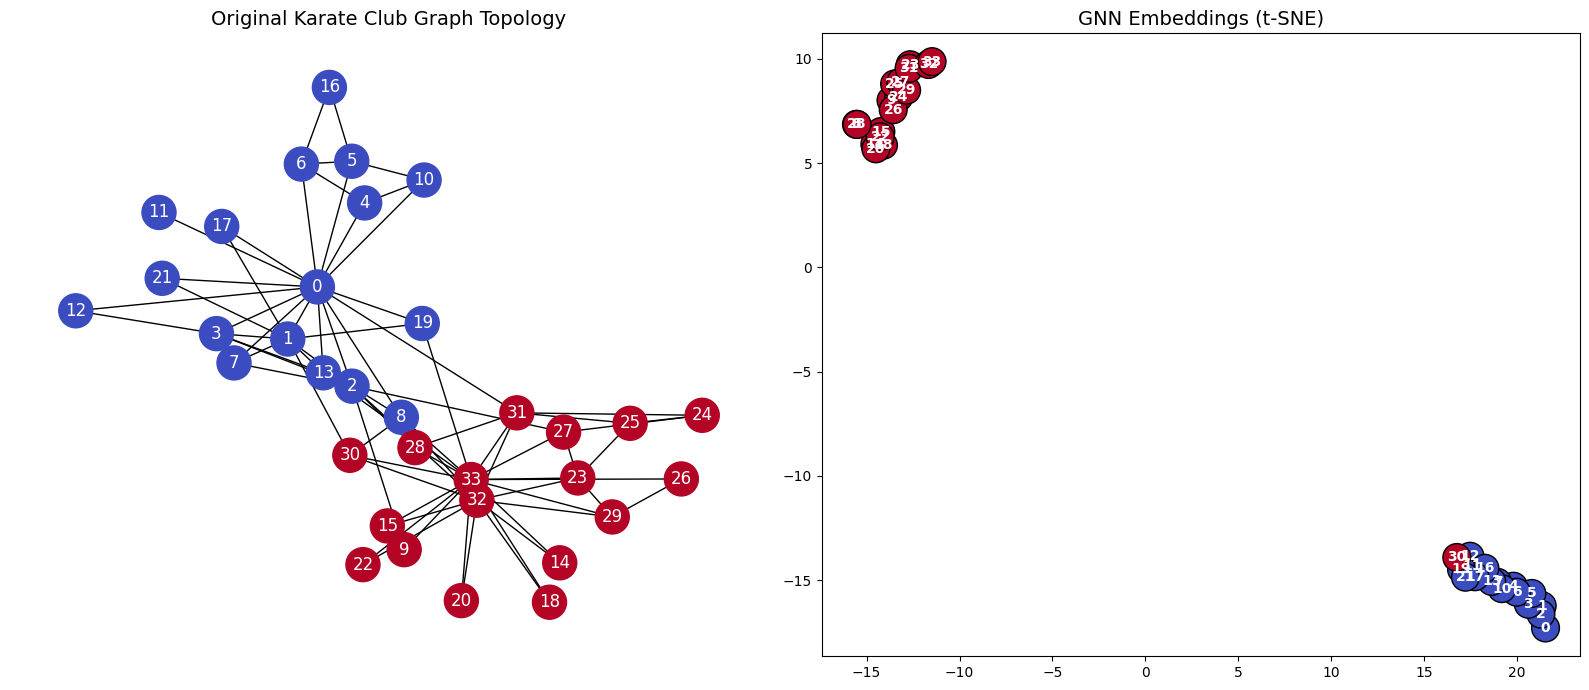

In [12]:
import numpy as np
import tensorflow as tf
import networkx as nx
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from sklearn.manifold import TSNE

# ============================================================
# 1. CUSTOM GCN LAYER
# ============================================================

class GCNLayer(layers.Layer):
    """Custom Graph Convolutional Layer."""
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        in_dim = input_shape[0][-1]
        self.w = self.add_weight(
            shape=(in_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="gcn_weight"
        )

    def call(self, inputs):
        # inputs is a list: [Node_Features, Adjacency_Matrix]
        X, A = inputs

        # X * W
        X_w = tf.matmul(X, self.w)
        # A * (X * W)
        output = tf.matmul(A, X_w)

        if self.activation:
            output = self.activation(output)

        return output

# ============================================================
# 2. DATA PREPARATION
# ============================================================

def prepare_karate_club_data():
    """Loads and pre-processes the Zachary's Karate Club dataset."""
    G = nx.karate_club_graph()
    N = G.number_of_nodes()

    # Features: Identity Matrix
    X = np.eye(N, dtype=np.float32)

    # Labels: 0 for 'Mr. Hi', 1 for 'Officer'
    labels = np.array([0 if G.nodes[i]['club'] == 'Mr. Hi' else 1 for i in G.nodes()])
    y = tf.keras.utils.to_categorical(labels)

    # Adjacency Matrix with Self-Loops
    A = nx.to_numpy_array(G, dtype=np.float32)
    A += np.eye(N)

    # Normalize Adjacency: D^(-1/2) * A * D^(-1/2)
    D = np.sum(A, axis=1)
    # where=D!=0 prevents divide-by-zero warnings on isolated nodes
    D_inv_sqrt = np.power(D, -0.5, where=D!=0)
    D_mat = np.diag(D_inv_sqrt)
    A_norm = (D_mat @ A @ D_mat).astype(np.float32)

    # Train/Test Split
    idx = np.arange(N)
    np.random.seed(42)
    np.random.shuffle(idx)

    train_idx, test_idx = idx[:24], idx[24:]

    train_mask = np.zeros(N, dtype=bool)
    train_mask[train_idx] = True

    test_mask = np.zeros(N, dtype=bool)
    test_mask[test_idx] = True

    return G, X, A_norm, y, train_mask, test_mask, labels

# ============================================================
# 3. MODEL ARCHITECTURE
# ============================================================

def build_model(num_nodes):
    """Builds the 2-layer GCN model."""
    X_in = layers.Input(shape=(num_nodes,), name="node_features")
    A_in = layers.Input(shape=(num_nodes,), name="adjacency_matrix")

    # Naming the hidden layer allows for safe, dynamic extraction later
    h = GCNLayer(16, activation="relu", name="hidden_gcn")([X_in, A_in])
    h_drop = layers.Dropout(0.5)(h)
    out = GCNLayer(2, activation="softmax", name="output_gcn")([h_drop, A_in])

    model = Model(inputs=[X_in, A_in], outputs=out, name="Karate_Club_GCN")
    return model

# ============================================================
# 4. VISUALIZATION
# ============================================================

def visualize_results(G, embeddings, true_classes):
    """Visualizes original graph topology and t-SNE embeddings side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Original Graph Visualization
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        node_color=true_classes,
        cmap=plt.cm.coolwarm,
        node_size=600,
        with_labels=True,
        font_color="white",
        ax=axes[0]
    )
    axes[0].set_title("Original Karate Club Graph Topology", fontsize=14)

    # Plot 2: t-SNE Visualization
    # Perplexity is lowered to 10 because N=34 (default 30 is too high for small graphs)
    emb_2d = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(embeddings)

    axes[1].scatter(
        emb_2d[:, 0], emb_2d[:, 1],
        c=true_classes,
        cmap="coolwarm",
        s=400,
        edgecolors="black"
    )

    for i in range(G.number_of_nodes()):
        axes[1].text(
            emb_2d[i, 0], emb_2d[i, 1], str(i),
            ha='center', va='center', color='white', fontweight='bold'
        )

    axes[1].set_title("GNN Embeddings (t-SNE)", fontsize=14)

    plt.tight_layout()
    plt.show()

# ============================================================
# 5. MAIN EXECUTION (TRAIN & EVALUATE)
# ============================================================

def main():
    # Load Data
    G, X, A_norm, y, train_mask, test_mask, true_classes = prepare_karate_club_data()
    N = G.number_of_nodes()

    # Build Model
    model = build_model(N)
    model.summary()

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    loss_fn = tf.keras.losses.CategoricalCrossentropy()

    # Training Loop
    print("\n--- Starting Training ---")
    epochs = 200
    for epoch in range(epochs + 1):
        with tf.GradientTape() as tape:
            preds = model([X, A_norm], training=True)
            # Apply boolean mask to only calculate loss on training nodes
            loss = loss_fn(y[train_mask], preds[train_mask])

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        if epoch % 20 == 0:
            pred_classes = tf.argmax(preds, axis=1).numpy()
            acc = np.mean(pred_classes[train_mask] == true_classes[train_mask])
            print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    # Evaluation
    preds = model([X, A_norm], training=False)
    pred_classes = tf.argmax(preds, axis=1).numpy()
    test_acc = np.mean(pred_classes[test_mask] == true_classes[test_mask])
    print(f"\n--- Final Test Accuracy: {test_acc:.4f} ---")

    # Extract Embeddings (Using exact layer name instead of indexing)
    embedding_model = Model(
        inputs=model.inputs,
        outputs=model.get_layer("hidden_gcn").output
    )
    embeddings = embedding_model([X, A_norm], training=False).numpy()
    print(f"Embeddings shape extracted successfully: {embeddings.shape}")

    # Visualize
    visualize_results(G, embeddings, true_classes)

if __name__ == "__main__":
    main()